# Threshold Tuning

This notebook evaluates probability thresholds for the binary classifiers in the hierarchical building-classification cascade and selects the thresholds used during final prediction.

**Input**
- Trained binary classification models.
- Validation or test data for the residential, industrial, and commercial classification tasks.

**Output**
- Selected probability thresholds for the binary classifiers.

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import (classification_report, f1_score, precision_score,
                              recall_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Directory config ──────────────────────────────────────────────────────────
ROOT_DIR  = '/fast/home/o-olajuyigbe/osm_project'
DATA_DIR  = os.path.join(ROOT_DIR, 'data')
ML_DIR    = os.path.join(DATA_DIR, 'ml_ready')
MODEL_DIR = os.path.join(DATA_DIR, 'models')
OUT_DIR   = os.path.join(DATA_DIR, 'final')
PROC_DIR  = os.path.join(DATA_DIR, 'processed')

# building file needed to validate that all building IDs are present in the final output
BUILDING_FILE = os.path.join(PROC_DIR, 'germany_buildings_feature_engineered.parquet')

FINAL_OUTPUT_FILE = os.path.join(OUT_DIR, 'germany_buildings_classified_final.parquet')

print(f"ML artefacts  : {ML_DIR}")
print(f"Model dir     : {MODEL_DIR}")
print(f"Output file   : {FINAL_OUTPUT_FILE}")


# LEVEL Options: 'flat_l1', 'flat_l2', 'l0_res_binary', 'l1a_res_subtypes',
#          'l1b_ind_binary', 'l2a_ind_subtypes', 'l2b_comm_binary', 'l3a_comm_subtypes'

LEVEL_res = 'l0_res_binary'
LEVEL_ind = 'l1b_ind_binary'
LEVEL_comm = 'l2b_comm_binary'



ML artefacts  : /fast/home/o-olajuyigbe/osm_project/data/ml_ready
Model dir     : /fast/home/o-olajuyigbe/osm_project/data/models
Output file   : /fast/home/o-olajuyigbe/osm_project/data/final/germany_buildings_classified_final.parquet


In [2]:
def load_level_data(level_name, ml_dir, model_dir):
    """
    Loads and inspects train, validation, and test sets for a given sector level.
    
    Parameters:
    - level_name (str): The prefix for the data (e.g., 'res', 'ind', 'comm').
    - ml_dir (str): The directory path where the .pkl files are stored.
    
    Returns:
    - Tuple containing X_train, y_train, X_val, y_val, X_test, y_test, classes, feature_cols
    """
    print(f"=== Loading data for: {level_name.upper()} ===")
    
    # Load Data for This Level
    X_train, y_train = joblib.load(os.path.join(ml_dir, f'{level_name}_train_raw.pkl'))
    X_val,   y_val   = joblib.load(os.path.join(ml_dir, f'{level_name}_val_raw.pkl'))
    X_test,  y_test  = joblib.load(os.path.join(ml_dir, f'{level_name}_test_raw.pkl'))
    classes          = joblib.load(os.path.join(ml_dir, f'{level_name}_classes.pkl'))
    
    # Assuming feature_cols is identical/shared across all levels. 
    # If it is level-specific, change this to f'{level_name}_feature_cols.pkl'
    feature_cols = joblib.load(os.path.join(model_dir, f'{level_name}_feature_cols.pkl'))
    print(f"  Slicing to {len(feature_cols)} selected features (was {X_train.shape[1]} candidate columns)")

    # Convert DataFrames to numpy if needed
    if hasattr(X_train, 'values'):
    
        X_train = X_train[feature_cols].values
        X_val   = X_val[feature_cols].values
        X_test  = X_test[feature_cols].values

    print(f"X_train : {X_train.shape}  |  Classes : {classes}  |  Features: {len(feature_cols)}")
    print("Class distribution — train:", np.bincount(y_train), " val:", np.bincount(y_val), " test:", np.bincount(y_test))
    print("-" * 40 + "\n")

    return X_train, y_train, X_val, y_val, X_test, y_test, classes, feature_cols




In [3]:
(X_train_res, y_train_res, X_val_res, y_val_res,
 X_test_res, y_test_res, classes_res, features_res) = load_level_data(LEVEL_res, ML_DIR, MODEL_DIR)

(X_train_ind, y_train_ind, X_val_ind, y_val_ind,
 X_test_ind, y_test_ind, classes_ind, features_ind) = load_level_data(LEVEL_ind, ML_DIR, MODEL_DIR)

(X_train_comm, y_train_comm, X_val_comm, y_val_comm,
 X_test_comm, y_test_comm, classes_comm, features_comm) = load_level_data(LEVEL_comm, ML_DIR, MODEL_DIR)


=== Loading data for: L0_RES_BINARY ===


  Slicing to 63 selected features (was 110 candidate columns)
X_train : (7772053, 63)  |  Classes : ['residential' 'non_residential']  |  Features: 63
Class distribution — train: [6600470 1171583]  val: [388263  68917]  test: [776527 137833]
----------------------------------------

=== Loading data for: L1B_IND_BINARY ===
  Slicing to 68 selected features (was 110 candidate columns)
X_train : (1171583, 68)  |  Classes : ['non_industrial' 'industrial']  |  Features: 68
Class distribution — train: [915114 256469]  val: [53831 15086]  test: [107660  30173]
----------------------------------------

=== Loading data for: L2B_COMM_BINARY ===
  Slicing to 70 selected features (was 110 candidate columns)
X_train : (915114, 70)  |  Classes : ['other' 'commercial']  |  Features: 70
Class distribution — train: [557339 357775]  val: [32785 21046]  test: [65569 42091]
----------------------------------------



In [4]:
# Evaluation Helper (used by every model)

def evaluate(model,X_test, y_test, classes, model_name, level, threshold=0.5):
    results = {}
        
    # Apply custom decision threshold to prediction probabilities
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
    else:
        y_pred = model.predict(X_test).astype(int)

    report = classification_report(y_test, y_pred, target_names=classes, output_dict=True)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    

    results['test'] = {
        'macro_f1'   : round(macro_f1, 4),
        'weighted_f1': round(weighted_f1, 4),
        'report'     : report,
        'threshold'  : round(threshold, 3)
    }
    print(f"\n{model_name} — {'test'.upper()} (Decision Threshold: {threshold:.3f})")
    print(f"  Macro F1    : {macro_f1:.4f}")
    print(f"  Weighted F1 : {weighted_f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=classes, digits=4))

    # Confusion matrix on test using optimized threshold
    if hasattr(model, "predict_proba"):
        y_prob_test = model.predict_proba(X_test)[:, 1]
        y_pred_test = (y_prob_test >= threshold).astype(int)
    else:
        y_pred_test = model.predict(X_test).astype(int)

    cm = confusion_matrix(y_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name} — {level} — Test Confusion Matrix')
    plt.tight_layout()
    plt.show()

    return results


all_results = {}  # accumulates results from all models for comparison

In [5]:

def optimize_threshold(target_model, level_name, model_dir, X_val, y_val):
    """
    Evaluates model probabilities and optimizes the classification threshold based on F1-Score.
    
    Parameters:
    - target_model (str): The name of the model ('lightgbm' or 'xgboost').
    - level_name (str): The prefix for the data level (e.g., 'res', 'ind', 'comm').
    - model_dir (str): Directory where the model .pkl files are stored.
    - X_val, y_val: Validation features and labels.
    
    Returns:
    - chosen_threshold (float): The optimal or manually selected threshold.
    - val_probs (ndarray): The predicted probabilities for the validation set.
    - test_probs (ndarray): The predicted probabilities for the test set.
    """
    print(f"\nLoading {target_model.upper()} model for level: {level_name.upper()}...")
    
    # Reload files securely to maintain isolated test execution integrity
    model_path = os.path.join(model_dir, f'{level_name}_{target_model}_optimized.pkl')
    model = joblib.load(model_path)

    # Extract probabilities once (assuming class 1 is the positive class)
    val_probs = model.predict_proba(X_val)[:, 1]

    # Use increments of 0.05 for a clean, readable table
    thresholds = np.arange(0.10, 0.95, 0.05)
    results = []
    
    # Calculate all three metrics for every threshold
    for t in thresholds:
        preds = (val_probs >= t).astype(int)
        f1   = f1_score(y_val, preds, average='binary')
        prec = precision_score(y_val, preds, average='binary', zero_division=0)
        rec  = recall_score(y_val, preds, average='binary')
        
        results.append({
            'Threshold': f"{t:.2f}",
            'Precision': f"{prec:.4f}",
            'Recall'   : f"{rec:.4f}",
            'F1-Score' : f"{f1:.4f}"
        })
        
    df_results = pd.DataFrame(results)
    
    print(f"\n{'='*45}")
    print(f" THRESHOLD OPTIMIZATION TABLE ({target_model.upper()})")
    print(f"{'='*45}")
    print(df_results.to_string(index=False))

    return model, val_probs
        
    

In [6]:
# Optimize threshold for Residential LightGBM
lgb_model_res = optimize_threshold(target_model='lightgbm', level_name=LEVEL_res,
    model_dir=MODEL_DIR, y_val=y_val_res,  X_val=X_val_res)


Loading LIGHTGBM model for level: L0_RES_BINARY...

 THRESHOLD OPTIMIZATION TABLE (LIGHTGBM)
Threshold Precision Recall F1-Score
     0.10    0.6609 0.9477   0.7787
     0.15    0.7140 0.9348   0.8096
     0.20    0.7501 0.9231   0.8276
     0.25    0.7765 0.9123   0.8389
     0.30    0.7985 0.9019   0.8471
     0.35    0.8173 0.8927   0.8533
     0.40    0.8338 0.8831   0.8577
     0.45    0.8477 0.8736   0.8604
     0.50    0.8611 0.8636   0.8623
     0.55    0.8721 0.8535   0.8627
     0.60    0.8827 0.8425   0.8622
     0.65    0.8932 0.8310   0.8610
     0.70    0.9036 0.8171   0.8582
     0.75    0.9140 0.8015   0.8541
     0.80    0.9242 0.7833   0.8479
     0.85    0.9345 0.7600   0.8382
     0.90    0.9464 0.7254   0.8213



LGB_MODEL_Final — TEST (Decision Threshold: 0.350)
  Macro F1    : 0.9132
  Weighted F1 : 0.9547
                 precision    recall  f1-score   support

    residential     0.9811    0.9642    0.9726    776527
non_residential     0.8161    0.8954    0.8539    137833

       accuracy                         0.9538    914360
      macro avg     0.8986    0.9298    0.9132    914360
   weighted avg     0.9562    0.9538    0.9547    914360



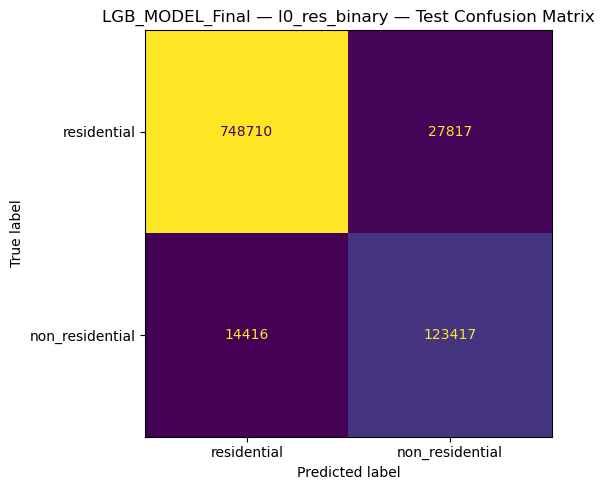

{'test': {'macro_f1': 0.9132,
  'weighted_f1': 0.9547,
  'report': {np.str_('residential'): {'precision': 0.9811092794636797,
    'recall': 0.9641776783035233,
    'f1-score': 0.9725697933235605,
    'support': 776527.0},
   np.str_('non_residential'): {'precision': 0.8160664929843818,
    'recall': 0.8954096624175633,
    'f1-score': 0.8538989230870352,
    'support': 137833.0},
   'accuracy': 0.9538114090730129,
   'macro avg': {'precision': 0.8985878862240307,
    'recall': 0.9297936703605433,
    'f1-score': 0.9132343582052979,
    'support': 914360.0},
   'weighted avg': {'precision': 0.9562303013928967,
    'recall': 0.9538114090730129,
    'f1-score': 0.9546810382847235,
    'support': 914360.0}},
  'threshold': 0.35}}

In [7]:
model_path = os.path.join(MODEL_DIR, f'{LEVEL_res}_lightgbm_optimized.pkl')

if lgb_model_res is None or not hasattr(lgb_model_res, "predict"):
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Missing model file: {model_path}")
    lgb_model_res = joblib.load(model_path)

if isinstance(lgb_model_res, tuple):
    lgb_model_res, _ = lgb_model_res

evaluate(lgb_model_res, X_test_res, y_test_res, classes_res,
    'LGB_MODEL_Final', LEVEL_res, threshold=0.35,)


In [8]:
# Use a hardcoded threshold for Industrial XGBoost
xgb_model_ind = optimize_threshold(target_model='xgboost', level_name=LEVEL_ind,
    model_dir=MODEL_DIR, y_val=y_val_ind,  X_val=X_val_ind)


Loading XGBOOST model for level: L1B_IND_BINARY...

 THRESHOLD OPTIMIZATION TABLE (XGBOOST)
Threshold Precision Recall F1-Score
     0.10    0.5702 0.9317   0.7075
     0.15    0.6230 0.9121   0.7403
     0.20    0.6613 0.8955   0.7608
     0.25    0.6915 0.8815   0.7750
     0.30    0.7166 0.8684   0.7852
     0.35    0.7378 0.8538   0.7916
     0.40    0.7572 0.8399   0.7964
     0.45    0.7749 0.8237   0.7986
     0.50    0.7932 0.8094   0.8012
     0.55    0.8086 0.7932   0.8008
     0.60    0.8241 0.7773   0.8000
     0.65    0.8377 0.7598   0.7969
     0.70    0.8547 0.7392   0.7927
     0.75    0.8699 0.7134   0.7840
     0.80    0.8867 0.6843   0.7725
     0.85    0.9042 0.6427   0.7514
     0.90    0.9217 0.5845   0.7154



XGB_MODEL_Final  - IND — TEST (Decision Threshold: 0.500)
  Macro F1    : 0.8690
  Weighted F1 : 0.9100
                precision    recall  f1-score   support

non_industrial     0.9455    0.9383    0.9419    107660
    industrial     0.7856    0.8071    0.7962     30173

      accuracy                         0.9096    137833
     macro avg     0.8656    0.8727    0.8690    137833
  weighted avg     0.9105    0.9096    0.9100    137833



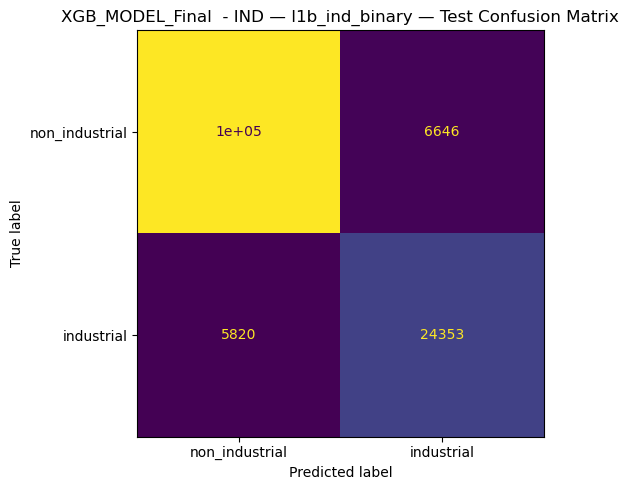

{'test': {'macro_f1': 0.869,
  'weighted_f1': 0.91,
  'report': {np.str_('non_industrial'): {'precision': 0.9455229608551585,
    'recall': 0.9382686234441762,
    'f1-score': 0.9418818242002107,
    'support': 107660.0},
   np.str_('industrial'): {'precision': 0.7856059872899126,
    'recall': 0.8071123189606602,
    'f1-score': 0.7962139540966455,
    'support': 30173.0},
   'accuracy': 0.9095572177925461,
   'macro avg': {'precision': 0.8655644740725356,
    'recall': 0.8726904712024182,
    'f1-score': 0.8690478891484281,
    'support': 137833.0},
   'weighted avg': {'precision': 0.9105155617316963,
    'recall': 0.9095572177925461,
    'f1-score': 0.909993694038095,
    'support': 137833.0}},
  'threshold': 0.5}}

In [9]:
model_path_ind = os.path.join(MODEL_DIR, f'{LEVEL_ind}_xgboost_optimized.pkl')

if xgb_model_ind is None or not hasattr(xgb_model_ind, "predict"):
    if not os.path.exists(model_path_ind):
        raise FileNotFoundError(f"Missing model file: {model_path_ind}")
    xgb_model_ind = joblib.load(model_path_ind)

if isinstance(xgb_model_ind, tuple):
    xgb_model_ind, _ = xgb_model_ind

evaluate(
    xgb_model_ind,
    X_test_ind,
    y_test_ind,
    classes_ind,
    'XGB_MODEL_Final  - IND',
    LEVEL_ind,
    threshold=0.50,
)


In [10]:
xgb_model_comm = optimize_threshold(target_model='xgboost', level_name=LEVEL_comm,
    model_dir=MODEL_DIR, y_val=y_val_comm,  X_val=X_val_comm)


Loading XGBOOST model for level: L2B_COMM_BINARY...

 THRESHOLD OPTIMIZATION TABLE (XGBOOST)
Threshold Precision Recall F1-Score
     0.10    0.6633 0.9744   0.7893
     0.15    0.7036 0.9629   0.8131
     0.20    0.7342 0.9517   0.8289
     0.25    0.7591 0.9405   0.8401
     0.30    0.7787 0.9290   0.8472
     0.35    0.7960 0.9172   0.8523
     0.40    0.8119 0.9066   0.8566
     0.45    0.8271 0.8921   0.8583
     0.50    0.8412 0.8797   0.8600
     0.55    0.8541 0.8656   0.8598
     0.60    0.8672 0.8499   0.8585
     0.65    0.8800 0.8330   0.8559
     0.70    0.8925 0.8135   0.8512
     0.75    0.9036 0.7919   0.8441
     0.80    0.9156 0.7645   0.8332
     0.85    0.9286 0.7307   0.8179
     0.90    0.9426 0.6826   0.7918



XGB_MODEL_Final - COMM — TEST (Decision Threshold: 0.400)
  Macro F1    : 0.8755
  Weighted F1 : 0.8802
              precision    recall  f1-score   support

       other     0.9342    0.8623    0.8968     65569
  commercial     0.8085    0.9054    0.8542     42091

    accuracy                         0.8792    107660
   macro avg     0.8714    0.8839    0.8755    107660
weighted avg     0.8851    0.8792    0.8802    107660



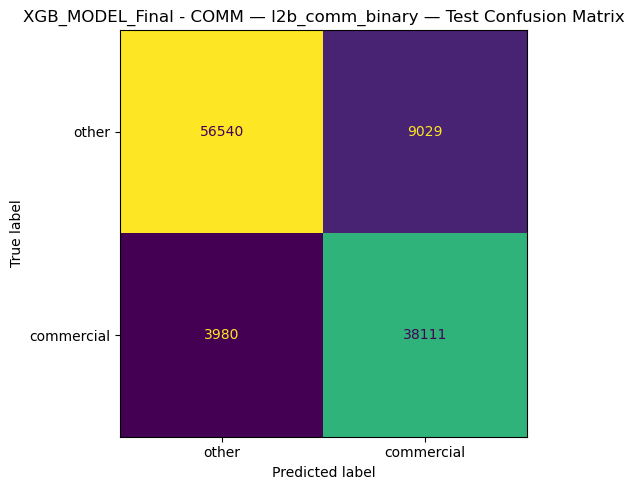

{'test': {'macro_f1': 0.8755,
  'weighted_f1': 0.8802,
  'report': {np.str_('other'): {'precision': 0.9342366159947125,
    'recall': 0.8622977321600146,
    'f1-score': 0.8968268445304507,
    'support': 65569.0},
   np.str_('commercial'): {'precision': 0.8084641493423844,
    'recall': 0.905442968805683,
    'f1-score': 0.8542098598020867,
    'support': 42091.0},
   'accuracy': 0.8791658926249304,
   'macro avg': {'precision': 0.8713503826685485,
    'recall': 0.8838703504828488,
    'f1-score': 0.8755183521662687,
    'support': 107660.0},
   'weighted avg': {'precision': 0.8850643245785585,
    'recall': 0.8791658926249304,
    'f1-score': 0.8801652106441274,
    'support': 107660.0}},
  'threshold': 0.4}}

In [11]:
model_path_comm = os.path.join(MODEL_DIR, f'{LEVEL_comm}_xgboost_optimized.pkl')

if xgb_model_comm is None or not hasattr(xgb_model_comm, "predict"):
    if not os.path.exists(model_path_comm):
        raise FileNotFoundError(f"Missing model file: {model_path_comm}")
    xgb_model_comm = joblib.load(model_path_comm)

if isinstance(xgb_model_comm, tuple):
    xgb_model_comm, _ = xgb_model_comm

evaluate(
    xgb_model_comm,
    X_test_comm,
    y_test_comm,
    classes_comm,
    'XGB_MODEL_Final - COMM',
    LEVEL_comm,
    threshold=0.40,
)
